# Проект: Определение возраста покупателей

## Введение

Сетевой супермаркет внедряет систему компьютерного зрения для обработки фотографий покупателей. Фотофиксация в прикассовой зоне поможет определять возраст клиентов, чтобы:
* Анализировать покупки и предлагать товары, которые могут заинтересовать покупателей этой возрастной группы;
* Контролировать добросовестность кассиров при продаже алкоголя.

## Цель проекта

Разработать и обучить нейронную сеть, способную определять примерный возраст человека по фотографии с использованием метода компьютерного зрения. Модель должна показать среднее абсолютное отклонение (MAE) между предсказанным и реальным возрастом менее 8 лет.

## Описание данных

В распоряжении имеется набор изображений лиц и таблица с метками:
* file_name — имя файла изображения,
* real_age — реальный возраст человека.

Данные предоставлены на основе открытого датасета ChaLearn Looking at People. <br>
Все изображения находятся в папке datasets/faces/final_files, а метки — в файле datasets/faces/labels.csv.

## План исследования

* [Исследовательский анализ данных](#link1)
* [Обучение модели](#link2)
* [Анализ модели](#link3)
* [Общий вывод](#link4)

## Подготовка рабочего пространства

In [1]:
# импортируем необходимые библиотеки
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import pandas as pd
import numpy as np
from PIL import Image
from IPython.display import display
import random
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


# подготовка GPU к обучению
import gc

tf.keras.backend.clear_session()
gc.collect()

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# расположение файлов
DATA_DIR = "datasets/faces/final_files"   # путь к изображениям
LABELS_PATH = "datasets/faces/labels.csv" # путь к labels.csv

<a class='anchor' id="link1"></a>
## 1 Исследовательский анализ данных

**1.1 Откроем файл с возрастными метками**

In [3]:
df = pd.read_csv(LABELS_PATH)

**1.2 Изучим общую информацию о датафрейме**

In [4]:
df.head()

,file_name,real_age
0,000000.jpg,4
1,000001.jpg,18
2,000002.jpg,80
3,000003.jpg,50
4,000004.jpg,17


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7591 entries, 0 to 7590
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   file_name  7591 non-null   str  
 1   real_age   7591 non-null   int64
dtypes: int64(1), str(1)
memory usage: 118.7 KB


Таблица с возрастными метками содержит 7591 строку и 2 столбца: столбец с названием фотографии и столбец с возрастом человека.

Пропусков нет. Типы данных соответствуют данным.

**1.3 Поиск дубликатов**

Поищем дубликаты в таблице

In [6]:
temp = df.duplicated().sum()
print(f"Имеется {temp} явных дубликатов.")

Имеется 0 явных дубликатов.


Посмотрим на наличие дубликатов в названиях фотографий

In [7]:
temp = df['file_name'].duplicated().sum()
print(f"Имеется {temp} дубликатов в названиях фотографий.")

Имеется 0 дубликатов в названиях фотографий.


**1.4 Статистический анализ**

Посмотрим статистическое описание данных.

In [8]:
df.describe()

,real_age
count,7591.000000
mean,31.201159
std,17.145060
min,1.000000
25%,20.000000
50%,29.000000
75%,41.000000
max,100.000000


В датасете представлены фотографии людей возрастом от 1 до 100 лет.

Средний возраст людей в датасете 31.2 года. 

Медианный возраст 29 лет.

Межквартильный разброс от 20 до 41 года.

Посторим, сколько уникальных значений в столбце с возрастами.

In [9]:
len(df['real_age'].unique())

97

In [10]:
missing_ages = set(range(1, 101)) - set(df['real_age'].unique())
print(sorted(missing_ages))

[92, 98, 99]


В датасете отсутствуют фотографии людей с возрастом 92, 98 и 99 лет.

Построим гистограммe и диаграммe размаха для распределения количества изображений людей по возрастам.<br>
Анализ распределения возраста важен, поскольку дисбаланс по возрастным группам может влиять на качество модели: нейросеть будет лучше предсказывать возраст для тех групп, которые чаще представлены в обучающей выборке.

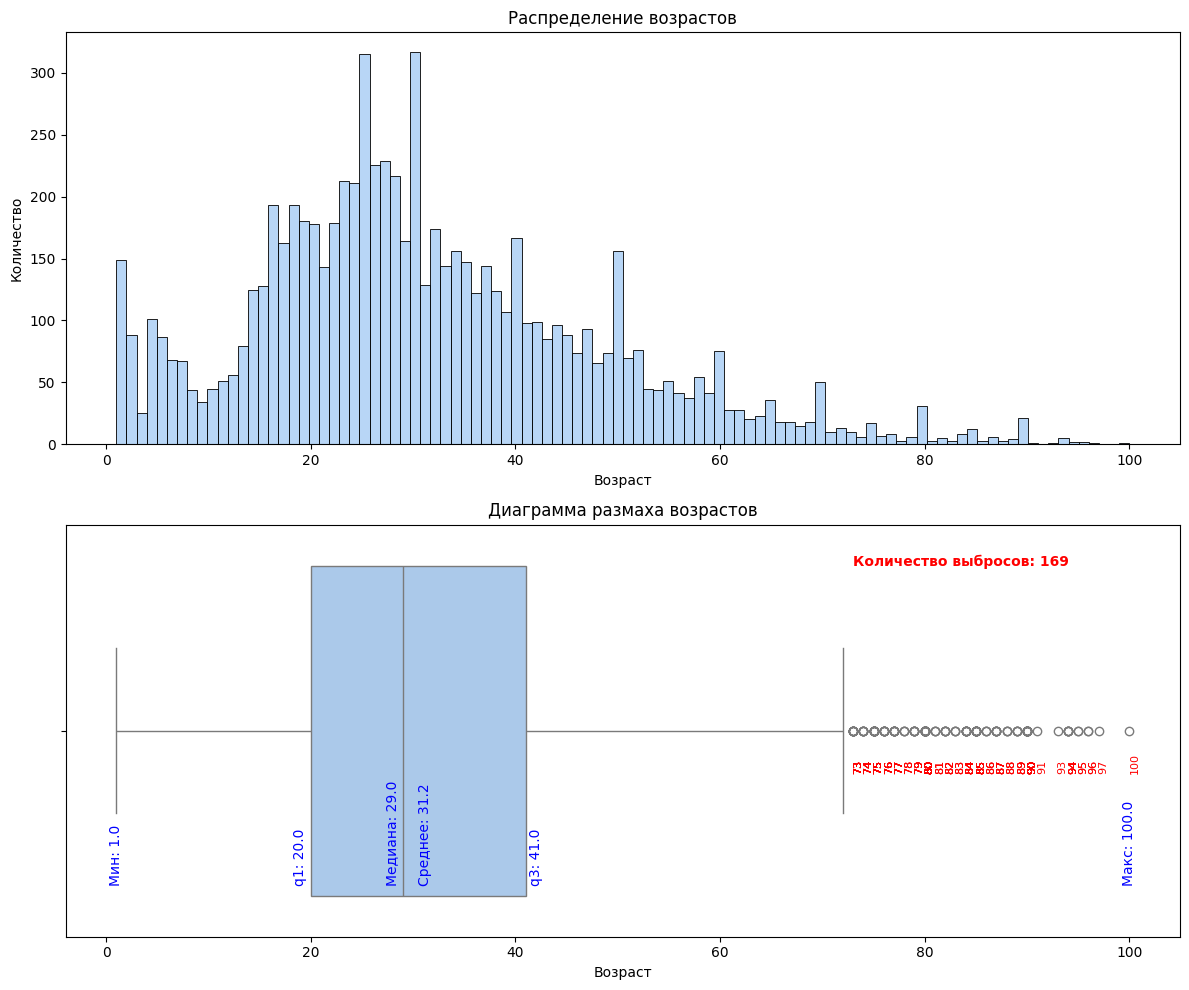

In [11]:
plt.figure(figsize=(12, 10))

# Гистограмма
plt.subplot(2, 1, 1)
sns.histplot(df['real_age'], bins=100, kde=False, color='#a1c9f4', edgecolor='black')
plt.title('Распределение возрастов')
plt.xlabel('Возраст')
plt.ylabel('Количество')

# Диаграмма размаха
plt.subplot(2, 1, 2)
box = sns.boxplot(x=df['real_age'], color='#a1c9f4')

# Статистика
data = df['real_age']
min_val = data.min()
max_val = data.max()
median_val = data.median()
mean_val = data.mean()
q1 = data.quantile(0.25)
q3 = data.quantile(0.75)
iqr = q3 - q1
outliers = data[(data < q1 - 1.5 * iqr) | (data > q3 + 1.5 * iqr)]

# Подписи
plt.text(min_val, 0.37, f'Мин: {min_val:.1f}', ha='center', color='blue', rotation=90)
plt.text(max_val, 0.37, f'Макс: {max_val:.1f}', ha='center', color='blue', rotation=90)
plt.text(median_val-1, 0.37, f'Медиана: {median_val:.1f}', ha='center', color='blue', rotation=90)
plt.text(mean_val, 0.37, f'Среднее: {mean_val:.1f}', ha='center', color='blue', rotation=90)
plt.text(q1-1, 0.37, f'q1: {q1:.1f}', ha='center', color='blue', rotation=90)
plt.text(q3+1, 0.37, f'q3: {q3:.1f}', ha='center', color='blue', rotation=90)

# Отметим выбросы
for outlier in outliers:
    plt.text(outlier, 0.1, f'{outlier:.0f}', rotation=90, color='red', fontsize=8)
    
# Подпись количества выбросов
plt.text(q3 + 32, -0.4, f'Количество выбросов: {len(outliers)}', 
         color='red', fontsize=10, fontweight='bold')

plt.xlabel('Возраст')
plt.title('Диаграмма размаха возрастов')

plt.tight_layout()
plt.show()

Распределение возрастов можно условно назвать нормальным с правым смещением. 

Диаграмма размаха показывает широкий диапазон возрастов и наличие крайних значений. Однако в контексте задачи такие наблюдения не следует считать ошибочными выбросами, поскольку они соответствуют реальным возрастам людей.

Есть всплеск количества фотографий детей в возрасте до 8 лет.

Имеются всплески количества фотографий для людей с круглыми возрастами (30, 40, ... , 90 лет). Это может объясняться округлением возраста в базе до ближайшего круглого числа.

**1.4 Изучение свойств, качества и состава фотографий**

Посмотрим несколько случайных изображений.

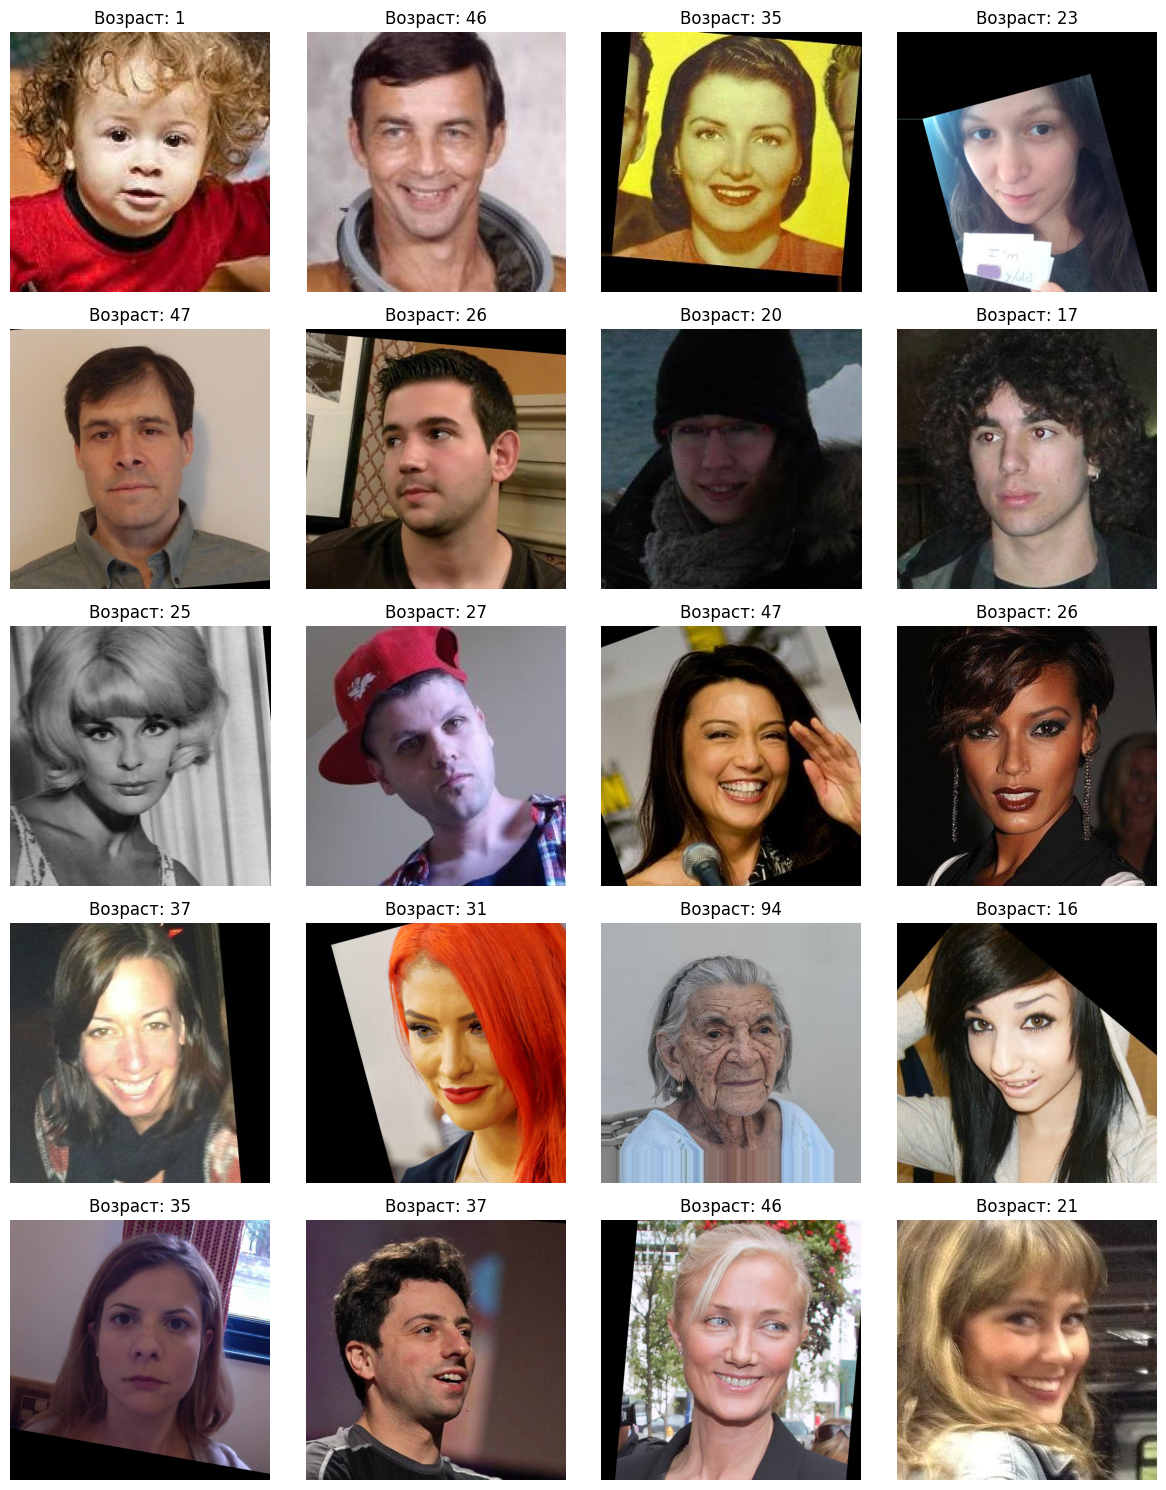

In [12]:
n = 20
sample = df.sample(n, random_state=42)
ncols = 4
nrows = (n + ncols - 1) // ncols

plt.figure(figsize=(12,15))
for i, (_, row) in enumerate(sample.iterrows()):
    fn = os.path.join(DATA_DIR, row['file_name'])
    try:
        img = Image.open(fn).convert('RGB')
    except Exception as e:
        print("Ошибка открытия", fn, e)
        continue
    plt.subplot(nrows, ncols, i+1)
    plt.imshow(img)
    plt.title(f"Возраст: {row['real_age']}")
    plt.axis('off')
plt.tight_layout()

Фотографии открылись без ошибок. 

Визуально определены несколько особенностей фотографий в датасете: 
* Имеются фотографии с наклонным ракурсом и обрезанные фотографии. 
* У фотографий разная резкость и освещенность.
* Имеются фотографии в анфас и с повернутыми лицами

Разнообразие ракурсов, освещённости и резкости увеличивает сложность задачи. Поэтому для повышения качества предсказаний модели будем использовать аугментацию изображений и предобученную модель ResNet50, уже умеющую извлекать устойчивые визуальные признаки.

Посмотрим на размеры фотографий в датасете

In [13]:
sizes = []
for fn in df['file_name'].tolist():
    path = os.path.join(DATA_DIR, fn)
    try:
        with Image.open(path) as im:
            sizes.append(im.size)  # (width, height)
    except:
        pass

sizes_df = pd.DataFrame(sizes, columns=['width','height'])
sizes_df['aspect ratio'] = sizes_df['width'] / sizes_df['height']

In [14]:
sizes_df.describe()

,width,height,aspect ratio
count,7591.000000,7591.000000,7591.000000
mean,464.733764,464.093927,1.002926
std,330.834794,331.289883,0.070334
min,47.000000,47.000000,0.466276
25%,220.000000,220.000000,1.000000
50%,385.000000,384.000000,1.000000
75%,632.000000,632.000000,1.000000
max,4466.000000,4466.000000,2.985075


В наборе представленны фотографии с размерами от 47 до 4466 пикселей по высоте и ширине. Большинство фотографий имеют соотношение сторон 1 к 1.

**Итог исследовательзкого анализа:**

В ходе исследовательского анализа данных изучены набор фотографий и файл с возрастными метками.

В датасете находится набор из 7591 фотографии людей с указанием их реального возраста. Таблица с возрастными метками содержит два столбца: имя файла изображения и возраст. Пропусков и несоответствий типов данных не обнаружено.

Выборка охватывает диапазон от 1 до 100 лет, однако значения 92, 98 и 99 лет отсутствуют. 

Средний возраст участников составляет 31.2 года, медианный — 29 лет.

Распределение возрастов близко к нормальному, но заметно смещено вправо. В выборке больше молодых людей, чем пожилых. Межквартильный разброс находится в пределах от 20 до 41 года.

Также наблюдается всплеск числа изображений детей до 8 лет и локальные пики для круглых возрастов (30, 40, 50 лет и т.д.), что, вероятно, связано с округлением возраста в источнике данных.

Все изображения успешно открываются. При визуальном осмотре выявлены различия в ракурсах, освещении и резкости. Встречаются портреты с поворотом головы, а также фотографии с неполным кадрированием лица (обрезанные фоторафии).

Размеры изображений варьируются от 47×47 до 4466×4466 пикселей, при этом основная часть фотографий имеет квадратное соотношение сторон (1:1).

Перед обучением модели данные необходимо нормализовать и провести аугментацию. С учётом этого набор данных можно считать пригодным для обучения нейронной сети.

<a class='anchor' id="link2"></a>
## 2 Обучение модели

В качестве базовой архитектуры выбрана **ResNet50**, предобученная на ImageNet.

Для подготовки данных использованы функции **load_train()** и **load_test()**. Они считывают файл с метками labels.csv, формируют генераторы изображений и автоматически разделяют выборку на обучающую и валидационную части. Для обучающей выборки дополнительно применяется аугментация изображений.

Функция **create_model()** формирует нейронную сеть на основе предобученной архитектуры ResNet50. В качестве выходного слоя используется один нейрон с линейной активацией, поскольку задача состоит в предсказании числового значения возраста.

Функция **train_model()** отвечает за обучение модели на обучающей выборке и контроль качества на валидационной. Для предотвращения переобучения используется механизм ранней остановки **EarlyStopping**, который сохраняет лучшие веса модели по метрике **val_mae**.

In [15]:
def load_train(path):
    
    # Чтение CSV с метками
    labels_df = pd.read_csv(os.path.join(path, "labels.csv"))

    # Создаём генератор
    datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=25,
        width_shift_range=0.1,
        height_shift_range=0.1,
        shear_range=0.1,
        zoom_range=0.1,
        horizontal_flip=True,
        brightness_range=[0.8, 1.2],
        channel_shift_range=20.0,
        validation_split=0.2
    )

    # Генератор обучающих данных
    train_generator = datagen.flow_from_dataframe(
        dataframe=labels_df,
        directory=os.path.join(path, "final_files"),
        x_col="file_name",
        y_col="real_age",
        target_size=(224, 224),
        batch_size=8,
        class_mode='raw',
        subset='training',
        seed=12345
    )

    return train_generator


def load_test(path):
    
    # Чтение CSV с метками
    labels_df = pd.read_csv(os.path.join(path, "labels.csv"))
    
    # Создаём генератор
    datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        validation_split=0.2
    )

    # Генератор валидационных данных
    val_generator = datagen.flow_from_dataframe(
        dataframe=labels_df,
        directory=os.path.join(path, "final_files"),
        x_col="file_name",
        y_col="real_age",
        target_size=(224, 224),
        batch_size=8,
        class_mode='raw',
        subset='validation',
        seed=12345
    )

    return val_generator


def create_model(input_shape=(224, 224, 3)):
    
    backbone = ResNet50(
        input_shape=input_shape,
        weights='datasets/keras_models/resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5',
        include_top=False
    )

    model = Sequential()
    model.add(backbone)
    model.add(GlobalAveragePooling2D())
    model.add(Dense(1, activation='linear'))
    
    optimizer = Adam(learning_rate=1e-4)
    
    model.compile(
        optimizer=optimizer,
        loss='mean_squared_error',
        metrics=['mae']
    )

    return model


def train_model(model, train_data, test_data, batch_size=None, epochs=15,
               steps_per_epoch=None, validation_steps=None):

    early_stop = EarlyStopping(
        monitor='val_mae',
        patience=3,
        restore_best_weights=True
    )

    model.fit(
        train_data,
        validation_data=test_data,
        batch_size=batch_size,
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        validation_steps=validation_steps,
        callbacks=[early_stop],
        verbose=2,
        shuffle=True
    )

    return model

In [16]:
DATA_PATH = 'datasets/faces/'

In [17]:
train_gen = load_train(DATA_PATH)
val_gen = load_test(DATA_PATH)

Found 6073 validated image filenames.
Found 1518 validated image filenames.


In [18]:
model = create_model()

In [19]:
model = train_model(model, train_gen, val_gen, epochs=10)

Epoch 1/10
760/760 - 286s - 377ms/step - loss: 193.7815 - mae: 10.4841 - val_loss: 139.8323 - val_mae: 9.4681
Epoch 2/10
760/760 - 139s - 183ms/step - loss: 124.9318 - mae: 8.4634 - val_loss: 87.0508 - val_mae: 7.0465
Epoch 3/10
760/760 - 130s - 171ms/step - loss: 103.1594 - mae: 7.7468 - val_loss: 115.3585 - val_mae: 8.4535
Epoch 4/10
760/760 - 128s - 169ms/step - loss: 92.8332 - mae: 7.3066 - val_loss: 95.0744 - val_mae: 7.4376
Epoch 5/10
760/760 - 140s - 184ms/step - loss: 85.1996 - mae: 6.9928 - val_loss: 116.9028 - val_mae: 8.3571


In [20]:
loss, mae = model.evaluate(val_gen)
print("MAE:", mae)

190/190 ━━━━━━━━━━━━━━━━━━━━ 14s 73ms/step - loss: 87.0508 - mae: 7.0465
MAE: 7.046520709991455


<a class='anchor' id="link3"></a>
## 3 Анализ обученной модели

Модель предсказания возраста покупателей создана на основе свёрточной нейронной сети ResNet50. Использование модели, предварительно обученной на наборе ImageNet, позволило применить transfer learning и использовать уже извлечённые базовые визуальные признаки.

Перед обучением изображения прошли процесс нормализации и аугментации (повороты, сдвиги, изменение масштаба, отражение и изменение яркости). Изображения предобрабатывались через preprocess_input библиотеки ResNet50, потому что ResNet50 обучалась на ImageNet, где входные изображения были предобработаны подобным образом.

Данные были разделены на обучающую и валидационную выборки через validation_split=0.2. В качестве оптимизатора использовалась функция Adam со скоростью обучения 1e-4. В качестве функции потерь использовалась MSE, а основной метрикой качества выступала MAE.

Размер батча был выбран 8. При большем размере батча обучение прерывалось (видеокарта NVIDIA GeForce GTX 1650 Ti с объемом памяти 4GB).

Минимальное значение **MAE** было достигнуто на второй эпохе и составило **7.05**, что удовлетворяет требованиям заказчика. Дальнейшее обучение не привело к устойчивому улучшению качества, что может свидетельствовать о начале переобучения.

<a class='anchor' id="link4"></a>
## Общий вывод

Целью проекта было разработать и обучить модель компьютерного зрения, способную определять примерный возраст человека по фотографии с метрикой **MAE&nbsp;менее&nbsp;8**.

В ходе работы был проведён исследовательский анализ данных. Он показал, что датасет содержит 7591 изображение, охватывает возрастной диапазон от 1 до 100 лет, не содержит пропусков и в целом пригоден для обучения модели. При этом были выявлены особенности, способные влиять на качество предсказаний: неравномерность распределения возрастов, всплеск числа фотографий детей, пики на круглых возрастах, а также различия в качестве, освещённости и ракурсе изображений.

Для решения задачи была построена и обучена **свёрточная нейросеть на базе предобученной архитектуры ResNet50**. Применение нормализации, аугментации и настройки гиперпараметров позволило достичь значения **MAE = 7.05**, что соответствует целевому показателю.

В дальнейшем качество модели можно повысить за счёт более тонкой настройки параметров оптимизатора и использования дополнительных техник регуляризации или других архитектур.